In [1]:
# ==== STEP 1: Project setup (paths, folders, core imports) ====
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Resolve project root (assumes this notebook is in a "notebooks" folder, but works anywhere)
NB_DIR = Path.cwd()
PROJ = NB_DIR if (NB_DIR / "data").exists() else NB_DIR.parent
DATA_RAW = PROJ / "data" / "raw"
DATA_PROC = PROJ / "data" / "processed"

# Create data folders
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)

print("Notebook dir :", NB_DIR)
print("Project root :", PROJ)
print("Raw data dir :", DATA_RAW)
print("Proc data dir:", DATA_PROC)

# Display pandas options for nicer previews
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

Notebook dir : C:\Users\Siddharth\Desktop\Energy_sentiment_analysis
Project root : C:\Users\Siddharth\Desktop
Raw data dir : C:\Users\Siddharth\Desktop\data\raw
Proc data dir: C:\Users\Siddharth\Desktop\data\processed


In [4]:
# ==== STEP 2 (final robust): detect 'DE_price_day_ahead' (new OPSD) and DE load, then aggregate daily ====
import pandas as pd

OPSD_URL = "https://data.open-power-system-data.org/time_series/latest/time_series_60min_singleindex.csv"

# 1) Read only the header
hdr = pd.read_csv(OPSD_URL, nrows=0)
cols = list(hdr.columns)

# 2) Find DE day-ahead price column (new OPSD uses 'DE_price_day_ahead')
def find_de_price(columns):
    # prioritize exact new name
    for c in columns:
        if c == "DE_price_day_ahead":
            return c
    # otherwise any 'DE' + 'price' + 'day' match
    candidates = [c for c in columns if c.startswith("DE_") and ("price" in c.lower()) and ("day" in c.lower())]
    # also try older DE_LU naming
    candidates += [c for c in columns if c.startswith("DE_LU") and ("price" in c.lower()) and ("day" in c.lower())]
    # deduplicate preserving order
    seen, uniq = set(), []
    for c in candidates:
        if c not in seen:
            uniq.append(c); seen.add(c)
    return uniq[0] if uniq else None

# 3) Find DE load column (most often 'DE_load_actual_entsoe_transparency')
def find_de_load(columns):
    # prefer the entsoe transparency one
    prefer = "DE_load_actual_entsoe_transparency"
    if prefer in columns:
        return prefer
    # fallback: any DE_*load*actual* column
    candidates = [c for c in columns if c.startswith("DE_") and ("load" in c.lower()) and ("actual" in c.lower())]
    if candidates:
        return candidates[0]
    # last resort: any DE_*load* column
    candidates = [c for c in columns if c.startswith("DE_") and ("load" in c.lower())]
    return candidates[0] if candidates else None

price_col = find_de_price(cols)
load_col  = find_de_load(cols)

if price_col is None:
    raise ValueError(
        "Could not find a DE day-ahead price column. "
        f"First 30 columns: {cols[:30]}"
    )
if load_col is None:
    raise ValueError(
        "Could not find a DE load column. "
        f"First 30 columns: {cols[:30]}"
    )

print(f"✓ Detected price column: {price_col}")
print(f"✓ Detected load  column: {load_col}")

# 4) Read the needed columns
use_cols = ["utc_timestamp", price_col, load_col]
print("Downloading OPSD with columns:", use_cols)
df_opsd = pd.read_csv(OPSD_URL, usecols=use_cols, parse_dates=["utc_timestamp"])

# 5) Standardize names
df_opsd = df_opsd.rename(columns={
    "utc_timestamp": "datetime_utc",
    price_col: "epex_dayahead_eur_mwh",
    load_col: "load_mw"
})

# 6) UTC→Europe/Berlin and daily aggregation
df_opsd["datetime_utc"] = pd.to_datetime(df_opsd["datetime_utc"], utc=True)
df_opsd["datetime_berlin"] = df_opsd["datetime_utc"].dt.tz_convert("Europe/Berlin")
df_opsd["date"] = pd.to_datetime(df_opsd["datetime_berlin"].dt.date)

daily = (df_opsd.groupby("date", as_index=False)
                 .agg(epex_price=("epex_dayahead_eur_mwh", "mean"),
                      load_mw=("load_mw", "mean"))
                 .sort_values("date")
                 .reset_index(drop=True))

daily_path = DATA_RAW / "opsd_de_daily.csv"
daily.to_csv(daily_path, index=False)
print(f"✅ Saved daily OPSD to {daily_path} | shape={daily.shape}")
daily.tail()

✓ Detected price column: DE_LU_price_day_ahead
✓ Detected load  column: DE_load_actual_entsoe_transparency
✅ Saved daily OPSD to C:\Users\Siddharth\Desktop\data\raw\opsd_de_daily.csv | shape=(2101, 3)


,date,epex_price,load_mw
2096,2020-09-27,30.026250,45154.541667
2097,2020-09-28,47.260417,56228.958333
2098,2020-09-29,58.618333,57823.958333
2099,2020-09-30,50.252917,57739.458333
2100,2020-10-01,34.400000,46173.500000


In [5]:
# ==== STEP 3: Optional Dutch TTF front-month (proxy driver) via yfinance ====
import pandas as pd

try:
    import yfinance as yf
    start_d = pd.to_datetime("2015-01-01")  # broad default
    # if we already built OPSD daily, align start/end to that range
    try:
        _opsd = pd.read_csv(DATA_RAW / "opsd_de_daily.csv", parse_dates=["date"])
        start_d = _opsd["date"].min()
        end_d   = _opsd["date"].max()
    except Exception:
        end_d = pd.Timestamp.today().normalize()

    print(f"Downloading TTF=F from {start_d.date()} to {end_d.date()} ...")
    ttf = yf.download("TTF=F", start=str(start_d.date()), end=str(end_d.date()), progress=False)

    if ttf is None or ttf.empty:
        print("⚠️ TTF returned empty. Continuing without gas proxy.")
        ttf = pd.DataFrame(columns=["date","ttf_price"])
    else:
        ttf = ttf.reset_index().rename(columns={"Date": "date", "Close": "ttf_price"})
        ttf["date"] = pd.to_datetime(ttf["date"])
        ttf = ttf[["date", "ttf_price"]]

    ttf_path = DATA_RAW / "ttf_daily.csv"
    ttf.to_csv(ttf_path, index=False)
    print(f"✅ Saved TTF to {ttf_path} | shape={ttf.shape}")
    display(ttf.tail())

except Exception as e:
    print("⚠️ TTF download failed (ok to continue without it):", repr(e))
    # create empty placeholder so later steps won't break
    pd.DataFrame(columns=["date","ttf_price"]).to_csv(DATA_RAW / "ttf_daily.csv", index=False)

C:\Users\Siddharth\AppData\Local\Temp\ipykernel_40596\2770964115.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ttf = yf.download("TTF=F", start=str(start_d.date()), end=str(end_d.date()), progress=False)


✅ Saved TTF to C:\Users\Siddharth\Desktop\data\raw\ttf_daily.csv | shape=(740, 2)


Price,date,ttf_price
Ticker,,TTF=F
735,2020-09-24,11.635
736,2020-09-25,11.665
737,2020-09-28,12.350
738,2020-09-29,12.280
739,2020-09-30,13.285


In [6]:
# ==== STEP 4: FinBERT on energy headlines -> daily sentiment table ====
import pandas as pd
from pathlib import Path

news_path = DATA_RAW / "news_energy.csv"

# 1) Create a small sample if you don't have a file yet (you can replace later)
if not news_path.exists():
    print("No news CSV found. Creating a small sample at:", news_path)
    sample = pd.DataFrame({
        "date": pd.date_range("2024-01-01", periods=20, freq="D"),
        "headline": [
            "German power prices rise amid low wind output",
            "Gas storage levels support bearish outlook for prices",
            "Grid congestion may widen price spreads across regions",
            "Wind forecast improves; prices could soften",
        ] * 5
    })
    sample.to_csv(news_path, index=False)

# 2) Load headlines (expects columns: date, headline)
news = pd.read_csv(news_path)
if "date" not in news.columns or "headline" not in news.columns:
    raise ValueError("news_energy.csv must have columns: 'date', 'headline'")

news["date"] = pd.to_datetime(news["date"]).dt.normalize()
news = news.dropna(subset=["headline"]).reset_index(drop=True)
print("Loaded headlines:", news.shape)

# 3) FinBERT inference (CPU is fine). It returns scores for positive/neutral/negative.
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

tok = AutoTokenizer.from_pretrained("ProsusAI/finbert")
mdl = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
clf = pipeline("text-classification", model=mdl, tokenizer=tok, return_all_scores=True, truncation=True)

def signed_score(text: str) -> float:
    out = clf(str(text))[0]              # list of dicts per label
    scores = {o["label"].lower(): o["score"] for o in out}
    # Map to a single signed score in [-1, 1]
    return scores.get("positive", 0.0) - scores.get("negative", 0.0)

# Run scoring with a safe .apply (can switch to tqdm later if large)
news["sent_score"] = news["headline"].apply(signed_score)

# 4) Aggregate to daily sentiment
daily_sent = (news.groupby("date", as_index=False)
                  .agg(mean_sent=("sent_score", "mean"),
                       n_headlines=("sent_score", "count")))
daily_sent["sent_smooth"] = daily_sent["mean_sent"].rolling(3, min_periods=1).mean()

# 5) Save & preview
sent_path = DATA_PROC / "daily_sentiment.csv"
daily_sent.to_csv(sent_path, index=False)
print(f"✅ Saved daily sentiment to {sent_path} | shape={daily_sent.shape}")
daily_sent.tail()

No news CSV found. Creating a small sample at: C:\Users\Siddharth\Desktop\data\raw\news_energy.csv
Loaded headlines: (20, 2)


Device set to use cpu
C:\Users\Siddharth\AppData\Roaming\Python\Python312\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


✅ Saved daily sentiment to C:\Users\Siddharth\Desktop\data\processed\daily_sentiment.csv | shape=(20, 4)


,date,mean_sent,n_headlines,sent_smooth
15,2024-01-16,0.764093,1,-0.034614
16,2024-01-17,-0.664073,1,-0.270948
17,2024-01-18,0.044929,1,0.048317
18,2024-01-19,-0.912864,1,-0.510669
19,2024-01-20,0.764093,1,-0.034614


In [7]:
# ==== STEP 4.1: Verify daily_sentiment; create neutral fallback covering all dates if needed ====
import pandas as pd

opsd = pd.read_csv(DATA_RAW / "opsd_de_daily.csv", parse_dates=["date"])
sent_path = DATA_PROC / "daily_sentiment.csv"

need_fallback = False
if not sent_path.exists():
    need_fallback = True
else:
    daily_sent = pd.read_csv(sent_path, parse_dates=["date"]).sort_values("date")
    print("Found daily_sentiment.csv:", daily_sent.shape)
    display(daily_sent.tail(3))
    # If it has very few rows (e.g., the tiny sample), you can switch to a neutral fallback for now.
    if len(daily_sent) < 30:   # tweak threshold as you like
        need_fallback = True
        print("⚠️ Very few sentiment rows -> creating a neutral fallback so features cover all dates.")

if need_fallback:
    daily_sent = opsd[["date"]].copy()
    daily_sent["mean_sent"]   = 0.0
    daily_sent["n_headlines"] = 0
    daily_sent["sent_smooth"] = 0.0
    daily_sent.to_csv(DATA_PROC / "daily_sentiment.csv", index=False)
    print("✅ Created NEUTRAL daily_sentiment.csv covering all OPSD dates:", daily_sent.shape)
    display(daily_sent.tail(3))

Found daily_sentiment.csv: (20, 4)


,date,mean_sent,n_headlines,sent_smooth
17,2024-01-18,0.044929,1,0.048317
18,2024-01-19,-0.912864,1,-0.510669
19,2024-01-20,0.764093,1,-0.034614


⚠️ Very few sentiment rows -> creating a neutral fallback so features cover all dates.
✅ Created NEUTRAL daily_sentiment.csv covering all OPSD dates: (2101, 4)


,date,mean_sent,n_headlines,sent_smooth
2098,2020-09-29,0.0,0,0.0
2099,2020-09-30,0.0,0,0.0
2100,2020-10-01,0.0,0,0.0


In [9]:
# ==== STEP 5 (patched): clean dtypes (especially TTF), merge, and rebuild features ====
import pandas as pd

# Load
opsd = pd.read_csv(DATA_RAW / "opsd_de_daily.csv", parse_dates=["date"])
sent = pd.read_csv(DATA_PROC / "daily_sentiment.csv", parse_dates=["date"])
try:
    ttf = pd.read_csv(DATA_RAW / "ttf_daily.csv", parse_dates=["date"])
except Exception:
    ttf = pd.DataFrame(columns=["date","ttf_price"])

# --- Coerce numeric types safely ---
# OPSD should already be numeric, but enforce:
for c in ["epex_price", "load_mw"]:
    if c in opsd.columns:
        opsd[c] = pd.to_numeric(opsd[c], errors="coerce")

# TTF sometimes saves as strings -> fix:
if not ttf.empty and "ttf_price" in ttf.columns:
    ttf["ttf_price"] = pd.to_numeric(ttf["ttf_price"], errors="coerce")

# Merge
df = opsd.merge(sent, on="date", how="left")
if not ttf.empty:
    df = df.merge(ttf, on="date", how="left")

# Fill missing
for c in ["mean_sent","sent_smooth"]:
    if c in df.columns:
        df[c] = df[c].fillna(0.0)
if "ttf_price" in df.columns:
    df["ttf_price"] = df["ttf_price"].ffill()

# --- Feature engineering ---
df["ret_1d"]   = df["epex_price"].pct_change()
df["fwd1_ret"] = df["epex_price"].pct_change().shift(-1)

for k in (1,2,3,5,7):
    df[f"sent_lag{k}"] = df["mean_sent"].shift(k)

df["ret_vol_10"] = df["ret_1d"].rolling(10).std()
df["load_chg"]   = df["load_mw"].pct_change()
df["load_z"]     = (df["load_mw"] - df["load_mw"].rolling(30).mean()) / df["load_mw"].rolling(30).std()

# TTF returns only if we have enough valid numeric points
if "ttf_price" in df.columns and pd.api.types.is_numeric_dtype(df["ttf_price"]):
    valid_ttf = df["ttf_price"].notna().sum()
    if valid_ttf >= 3:
        df["ttf_ret_1d"] = df["ttf_price"].pct_change()
        for k in (1,2,3):
            df[f"ttf_ret_lag{k}"] = df["ttf_ret_1d"].shift(k)
    else:
        print(f"⚠️ TTF has only {valid_ttf} valid points; skipping ttf returns.")

# Finalize
feat = df.dropna().reset_index(drop=True)
feat_path = DATA_PROC / "features_daily.csv"
feat.to_csv(feat_path, index=False)
print(f"✅ Saved features to {feat_path} | shape={feat.shape}")
feat.tail()

✅ Saved features to C:\Users\Siddharth\Desktop\data\processed\features_daily.csv | shape=(721, 21)


,date,epex_price,load_mw,mean_sent,n_headlines,sent_smooth,ttf_price,ret_1d,fwd1_ret,sent_lag1,sent_lag2,sent_lag3,sent_lag5,sent_lag7,ret_vol_10,load_chg,load_z,ttf_ret_1d,ttf_ret_lag1,ttf_ret_lag2,ttf_ret_lag3
716,2020-09-26,33.130833,48826.250000,0.0,0,0.0,11.665,-0.199190,-0.093707,0.0,0.0,0.0,0.0,0.0,0.245838,-0.127220,-0.608470,0.000000,0.002578,-0.032030,0.026912
717,2020-09-27,30.026250,45154.541667,0.0,0,0.0,11.665,-0.093707,0.573970,0.0,0.0,0.0,0.0,0.0,0.244318,-0.075199,-1.253044,0.000000,0.000000,0.002578,-0.032030
718,2020-09-28,47.260417,56228.958333,0.0,0,0.0,12.350,0.573970,0.240326,0.0,0.0,0.0,0.0,0.0,0.305902,0.245256,0.842808,0.058723,0.000000,0.000000,0.002578
719,2020-09-29,58.618333,57823.958333,0.0,0,0.0,12.280,0.240326,-0.142710,0.0,0.0,0.0,0.0,0.0,0.304524,0.028366,1.112253,-0.005668,0.058723,0.000000,0.000000
720,2020-09-30,50.252917,57739.458333,0.0,0,0.0,13.285,-0.142710,-0.315463,0.0,0.0,0.0,0.0,0.0,0.312586,-0.001461,1.045754,0.081840,-0.005668,0.058723,0.000000


In [10]:
# ==== STEP 6.1: Load features, pick target, build X/y, and split chronologically ====
import pandas as pd
import numpy as np
from pathlib import Path

# Load the processed features
feat_path = DATA_PROC / "features_daily.csv"
feat = pd.read_csv(feat_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print("Features loaded:", feat.shape)
display(feat.tail(3))

# Target: next-day return on EPEX (built in Step 5 as 'fwd1_ret')
target = "fwd1_ret"
if target not in feat.columns:
    raise ValueError(f"Target '{target}' not found in features.")

# Columns we must NOT feed to the model (ID/date/targets/leaky cols)
drop_cols = {"date", "epex_price", "fwd1_ret"}  # extend here if you add other obvious leaks
X = feat.drop(columns=[c for c in drop_cols if c in feat.columns])
y = feat[target].astype(float)

# Chronological split (75% train / 25% test)
split_idx = int(len(feat) * 0.75)
X_tr, X_te = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_tr, y_te = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
dates_te  = feat.loc[split_idx:, "date"].reset_index(drop=True)

print(f"Train size: {len(X_tr)} | Test size: {len(X_te)}")
print("X columns:", list(X.columns)[:12], "...")

Features loaded: (721, 21)


,date,epex_price,load_mw,mean_sent,n_headlines,sent_smooth,ttf_price,ret_1d,fwd1_ret,sent_lag1,sent_lag2,sent_lag3,sent_lag5,sent_lag7,ret_vol_10,load_chg,load_z,ttf_ret_1d,ttf_ret_lag1,ttf_ret_lag2,ttf_ret_lag3
718,2020-09-28,47.260417,56228.958333,0.0,0,0.0,12.350,0.573970,0.240326,0.0,0.0,0.0,0.0,0.0,0.305902,0.245256,0.842808,0.058723,0.000000,0.000000,0.002578
719,2020-09-29,58.618333,57823.958333,0.0,0,0.0,12.280,0.240326,-0.142710,0.0,0.0,0.0,0.0,0.0,0.304524,0.028366,1.112253,-0.005668,0.058723,0.000000,0.000000
720,2020-09-30,50.252917,57739.458333,0.0,0,0.0,13.285,-0.142710,-0.315463,0.0,0.0,0.0,0.0,0.0,0.312586,-0.001461,1.045754,0.081840,-0.005668,0.058723,0.000000


Train size: 540 | Test size: 181
X columns: ['load_mw', 'mean_sent', 'n_headlines', 'sent_smooth', 'ttf_price', 'ret_1d', 'sent_lag1', 'sent_lag2', 'sent_lag3', 'sent_lag5', 'sent_lag7', 'ret_vol_10'] ...


In [12]:
# ==== STEP 6.2a: install xgboost ====
!pip install xgboost --quiet

In [13]:
# ==== STEP 6.2: Train XGBoost model and evaluate performance ====
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Define the model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror"
)

# Train
model.fit(X_tr, y_tr)
pred_te = model.predict(X_te)

# Evaluate
mae = mean_absolute_error(y_te, pred_te)
corr = np.corrcoef(y_te, pred_te)[0,1]
print(f"✅ Test MAE: {mae:.6f}")
print(f"📊 Corr(y_true, y_pred): {corr:.3f}")

# Append predictions for later backtesting
results = pd.DataFrame({
    "date": dates_te,
    "y_true": y_te.values,
    "y_pred": pred_te
})
display(results.tail(5))

✅ Test MAE: 0.651709
📊 Corr(y_true, y_pred): 0.292


,date,y_true,y_pred
176,2020-09-26,-0.093707,-0.138873
177,2020-09-27,0.573970,0.045967
178,2020-09-28,0.240326,0.094128
179,2020-09-29,-0.142710,-0.012994
180,2020-09-30,-0.315463,0.068236


Pct-Return Strategy | CAGR: -99.95% | Sharpe: -1.56 | MaxDD: -99.74%


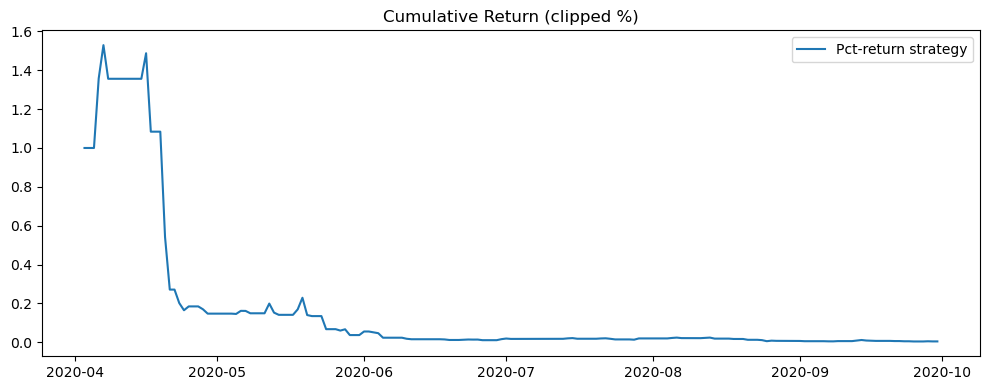

Points-PnL Strategy | Total PnL (€/MWh): nan


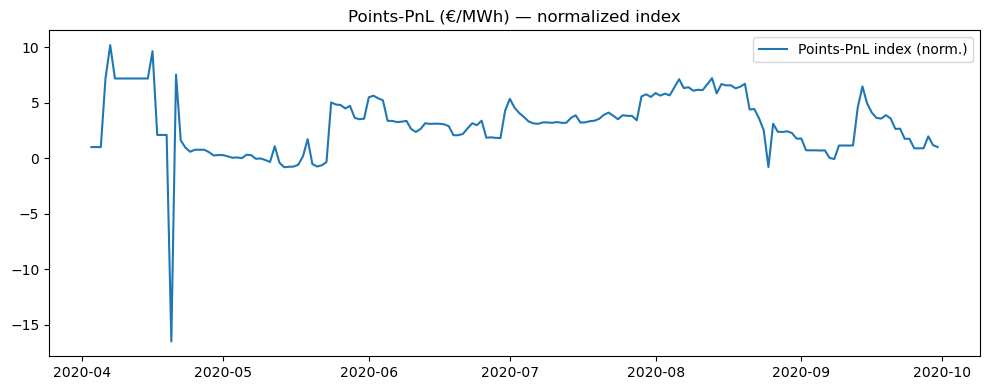

In [16]:
# ==== STEP 6.3-fix: robust backtest for power prices ====
import numpy as np
import matplotlib.pyplot as plt

bt = results.copy()

# 1) Trading rule (same as before)
bt["signal"] = (bt["y_pred"] > 0).astype(int)

# 2) Robust percent-return backtest (clip extremes so negative/near-zero prices don't explode)
pct_true = bt["y_true"].replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-0.5, 0.5)
bt["strategy_ret"] = bt["signal"].shift(1).fillna(0) * pct_true
bt["cum_ret"] = (1 + bt["strategy_ret"]).cumprod()

def sharpe_ratio(r, rf=0.0):
    sd = r.std()
    if len(r) < 2 or sd == 0 or np.isnan(sd):
        return 0.0
    return (r.mean() - rf) / sd * np.sqrt(252)

def cagr(series, days_per_year=252):
    s = series.clip(lower=1e-6)
    if len(s) < 2:
        return 0.0
    start, end = s.iloc[0], s.iloc[-1]
    years = len(s) / days_per_year
    return (end / start) ** (1 / years) - 1

def max_drawdown(series):
    s = series.clip(lower=1e-6)
    dd = s / s.cummax() - 1
    return dd.min()

sr = sharpe_ratio(bt["strategy_ret"].fillna(0))
cg = cagr(bt["cum_ret"])
mdd = max_drawdown(bt["cum_ret"])

print(f"Pct-Return Strategy | CAGR: {cg:.2%} | Sharpe: {sr:.2f} | MaxDD: {mdd:.2%}")

plt.figure(figsize=(10,4))
plt.plot(bt["date"], bt["cum_ret"], label="Pct-return strategy")
plt.title("Cumulative Return (clipped %)")
plt.legend(); plt.tight_layout(); plt.show()

# 3) ALSO show a points-PnL (€/MWh) backtest — safer for power markets
#    Use actual price changes from the test slice aligned with our predictions
test_slice = feat.iloc[split_idx:].copy()
test_slice = test_slice[["date","epex_price"]].reset_index(drop=True)
test_slice["price_change"] = test_slice["epex_price"].diff().shift(-1)  # next-day price change in €/MWh

bt_points = test_slice[["date","price_change"]].copy()
bt_points["signal"] = bt["signal"].values
bt_points["pnl"] = bt_points["signal"].shift(1).fillna(0) * bt_points["price_change"]
bt_points["cum_pnl"] = bt_points["pnl"].cumsum()

# Normalize to an index for plotting (start at 1.0)
index0 = 1.0 + bt_points["cum_pnl"] / (np.abs(bt_points["price_change"]).rolling(20).mean().fillna(1.0))
index0 = index0.fillna(1.0)

print(f"Points-PnL Strategy | Total PnL (€/MWh): {bt_points['cum_pnl'].iloc[-1]:.2f}")

plt.figure(figsize=(10,4))
plt.plot(bt_points["date"], index0, label="Points-PnL index (norm.)")
plt.title("Points-PnL (€/MWh) — normalized index")
plt.legend(); plt.tight_layout(); plt.show()

In [17]:
# ==== STEP 7.1: Rebuild features to use price changes (€/MWh) ====
import pandas as pd
import numpy as np

opsd = pd.read_csv(DATA_RAW / "opsd_de_daily.csv", parse_dates=["date"])
sent = pd.read_csv(DATA_PROC / "daily_sentiment.csv", parse_dates=["date"])
try:
    ttf = pd.read_csv(DATA_RAW / "ttf_daily.csv", parse_dates=["date"])
except Exception:
    ttf = pd.DataFrame(columns=["date","ttf_price"])

# Coerce numeric just in case
for c in ["epex_price","load_mw"]:
    if c in opsd.columns:
        opsd[c] = pd.to_numeric(opsd[c], errors="coerce")
if not ttf.empty and "ttf_price" in ttf.columns:
    ttf["ttf_price"] = pd.to_numeric(ttf["ttf_price"], errors="coerce")

# Merge
df = opsd.merge(sent, on="date", how="left")
if not ttf.empty:
    df = df.merge(ttf, on="date", how="left")

# Fill sentiment gaps & TTF ffill
for c in ["mean_sent","sent_smooth"]:
    if c in df: df[c] = df[c].fillna(0.0)
if "ttf_price" in df: df["ttf_price"] = df["ttf_price"].ffill()

# --- Price change features/targets ---
# Daily price change in €/MWh
df["dprice_1d"]   = df["epex_price"].diff()
df["fwd1_dprice"] = df["epex_price"].shift(-1) - df["epex_price"]   # TARGET

# Lagged price changes & sentiment lags
for k in (1,2,3,5,7):
    df[f"dprice_lag{k}"] = df["dprice_1d"].shift(k)
    df[f"sent_lag{k}"]   = df["mean_sent"].shift(k)

# Load dynamics
df["load_chg"] = df["load_mw"].pct_change()
df["load_z"]   = (df["load_mw"] - df["load_mw"].rolling(30).mean()) / df["load_mw"].rolling(30).std()

# Volatility proxy on price changes
df["dprice_vol_10"] = df["dprice_1d"].rolling(10).std()

# Optional gas driver in price-change space
if "ttf_price" in df.columns:
    df["ttf_d1"] = df["ttf_price"].diff()
    for k in (1,2,3):
        df[f"ttf_d1_lag{k}"] = df["ttf_d1"].shift(k)

# Drop rows created by lags
feat_px = df.dropna().reset_index(drop=True)

# Save
feat_px_path = DATA_PROC / "features_daily_dprice.csv"
feat_px.to_csv(feat_px_path, index=False)
print(f"✅ Saved: {feat_px_path} | shape={feat_px.shape}")
feat_px.tail(3)

✅ Saved: C:\Users\Siddharth\Desktop\data\processed\features_daily_dprice.csv | shape=(721, 26)


,date,epex_price,load_mw,mean_sent,n_headlines,sent_smooth,ttf_price,dprice_1d,fwd1_dprice,dprice_lag1,sent_lag1,dprice_lag2,sent_lag2,dprice_lag3,sent_lag3,dprice_lag5,sent_lag5,dprice_lag7,sent_lag7,load_chg,load_z,dprice_vol_10,ttf_d1,ttf_d1_lag1,ttf_d1_lag2,ttf_d1_lag3
718,2020-09-28,47.260417,56228.958333,0.0,0,0.0,12.350,17.234167,11.357917,-3.104583,0.0,-8.240833,0.0,3.187500,0.0,-6.885000,0.0,23.580417,0.0,0.245256,0.842808,11.285498,0.685000,0.000000,0.000,0.03
719,2020-09-29,58.618333,57823.958333,0.0,0,0.0,12.280,11.357917,-8.365417,17.234167,0.0,-3.104583,0.0,-8.240833,0.0,-8.244167,0.0,-7.782083,0.0,0.028366,1.112253,11.536865,-0.070001,0.685000,0.000,0.00
720,2020-09-30,50.252917,57739.458333,0.0,0,0.0,13.285,-8.365417,-15.852917,11.357917,0.0,17.234167,0.0,-3.104583,0.0,3.187500,0.0,-6.885000,0.0,-0.001461,1.045754,12.015961,1.005000,-0.070001,0.685,0.00


In [18]:
# ==== STEP 7.2: Train model to predict next-day price change (€/MWh) ====
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

feat_px = pd.read_csv(DATA_PROC / "features_daily_dprice.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

target = "fwd1_dprice"
drop_cols = {"date", "epex_price", "fwd1_dprice"}  # remove ID/leak cols
X = feat_px.drop(columns=[c for c in drop_cols if c in feat_px.columns])
y = feat_px[target].astype(float)

# Chronological split
split_idx = int(len(feat_px)*0.75)
X_tr, X_te = X.iloc[:split_idx], X.iloc[split_idx:]
y_tr, y_te = y.iloc[:split_idx], y.iloc[split_idx:]
dates_te   = feat_px.loc[split_idx:, "date"].reset_index(drop=True)
prices_te  = feat_px.loc[split_idx:, "epex_price"].reset_index(drop=True)  # for PnL calc

# Model
model_px = XGBRegressor(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)
model_px.fit(X_tr, y_tr)
pred_te = model_px.predict(X_te)

mae_px = mean_absolute_error(y_te, pred_te)
corr_px = np.corrcoef(y_te, pred_te)[0,1]
print(f"✅ Test MAE (€/MWh): {mae_px:.3f}")
print(f"📊 Corr(y_true, y_pred): {corr_px:.3f}")

# Keep test frame for backtest
px_res = pd.DataFrame({"date": dates_te, "true_dprice": y_te.values, "pred_dprice": pred_te})
px_res.tail(5)

✅ Test MAE (€/MWh): 6.579
📊 Corr(y_true, y_pred): 0.561


,date,true_dprice,pred_dprice
176,2020-09-26,-3.104583,-0.461618
177,2020-09-27,17.234167,9.421132
178,2020-09-28,11.357917,-5.058738
179,2020-09-29,-8.365417,0.514956
180,2020-09-30,-15.852917,-2.029154


Points-PnL Strategy | Trades: 54 | Sharpe: 2.10 | MaxDD: -3591.00%


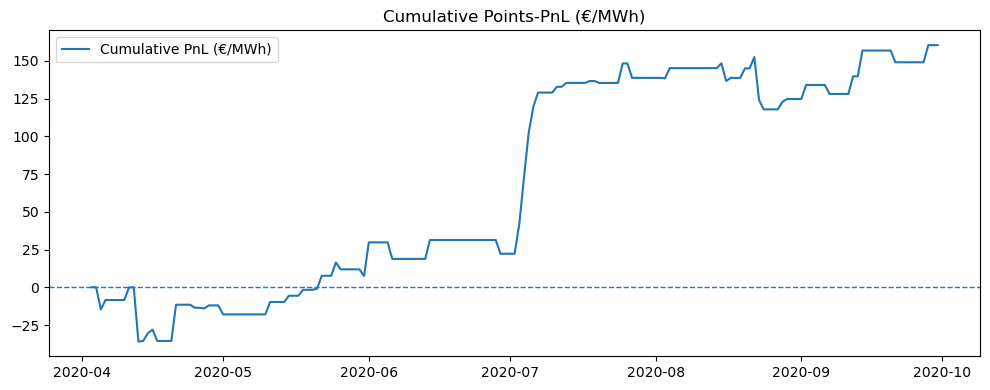

In [19]:
# ==== STEP 7.3: Points-PnL backtest (€/MWh) with prediction thresholding ====
import numpy as np
import matplotlib.pyplot as plt

bt = px_res.copy()

# Trade only when |prediction| is strong:
# Use a quantile threshold on absolute predicted change
th = bt["pred_dprice"].abs().quantile(0.7)   # try 0.7; raise to 0.8 for fewer trades
bt["signal"] = 0
bt.loc[bt["pred_dprice"] >  th, "signal"] = 1   # long if strong positive move predicted
bt.loc[bt["pred_dprice"] < -th, "signal"] = -1  # short if strong negative move predicted

# Next-day execution (enter at t using signal from t-1)
bt["signal_shift"] = bt["signal"].shift(1).fillna(0)

# PnL in €/MWh
bt["pnl"] = bt["signal_shift"] * bt["true_dprice"]
bt["cum_pnl"] = bt["pnl"].cumsum()

def sharpe(pnl):
    s = pnl.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    sd = s.std()
    if len(s) < 2 or sd == 0 or np.isnan(sd): return 0.0
    return s.mean() / sd * np.sqrt(252)

def maxdd_from_pnl(cum_pnl):
    eq = 1.0 + cum_pnl / (np.abs(cum_pnl).rolling(50).mean().fillna(1.0))  # normalized equity for drawdown
    dd = eq / eq.cummax() - 1
    return dd.min()

sr = sharpe(bt["pnl"])
mdd = maxdd_from_pnl(bt["cum_pnl"])
print(f"Points-PnL Strategy | Trades: {int((bt['signal']!=0).sum())} | Sharpe: {sr:.2f} | MaxDD: {mdd:.2%}")

plt.figure(figsize=(10,4))
plt.plot(bt["date"], bt["cum_pnl"], label="Cumulative PnL (€/MWh)")
plt.axhline(0, ls="--", lw=1)
plt.title("Cumulative Points-PnL (€/MWh)")
plt.legend(); plt.tight_layout(); plt.show()